In [2]:
#Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Load Dataset

df = pd.read_csv("/workspaces/AI-and-NN/FinalProject/Stock_Price_Data.csv")

print(df.head())

print("\nShape:", df.shape)

print("\nInformation")
print(df.info())

print("\nSummary Statistics")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1  1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2  1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3  1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4  1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400

Shape: (9909, 7)

Information
<class 'pandas.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   str    
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 542.0 K

In [3]:
# Data Preprocessing

# Convert "Date" column to datetime format and set it as the index

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.set_index("Date", inplace=True)

df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [10]:
# Check column names and data types

print(df.columns)

print(df.dtypes)

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


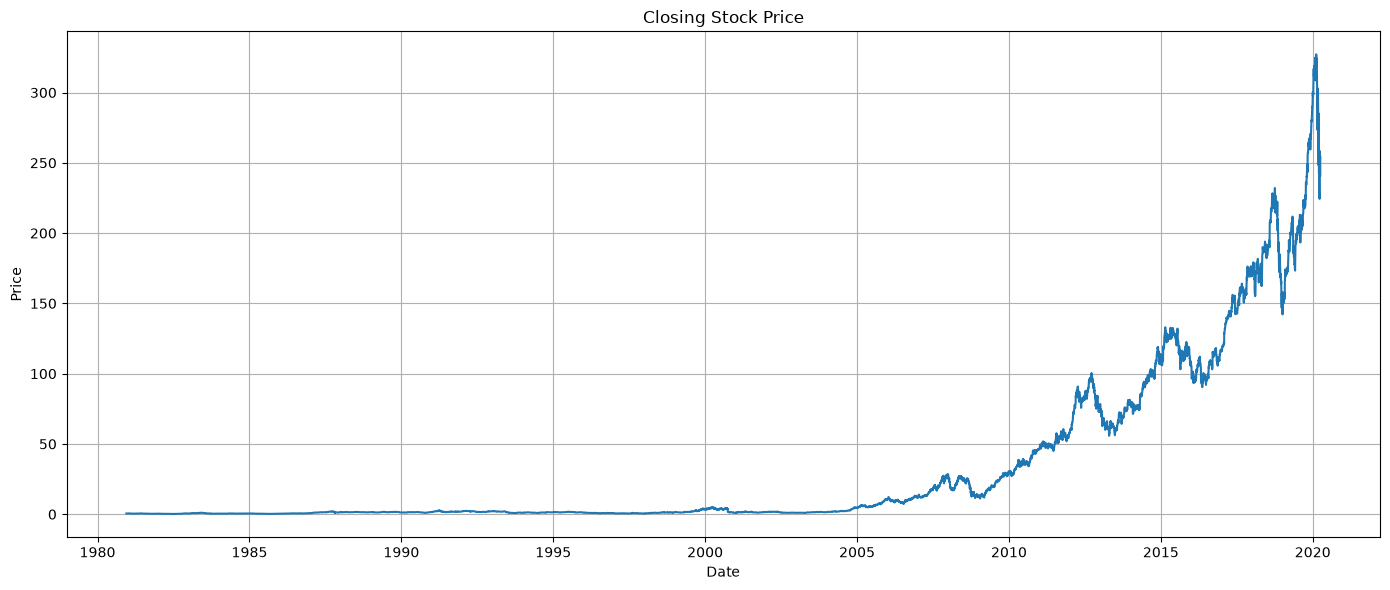

In [11]:
# Visualize the Closing Stock Price

plt.figure(figsize=(14,6))
plt.plot(df["Close"])
plt.title("Closing Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.tight_layout()
plt.savefig("closing_stock_price.png", dpi=300)
plt.show()

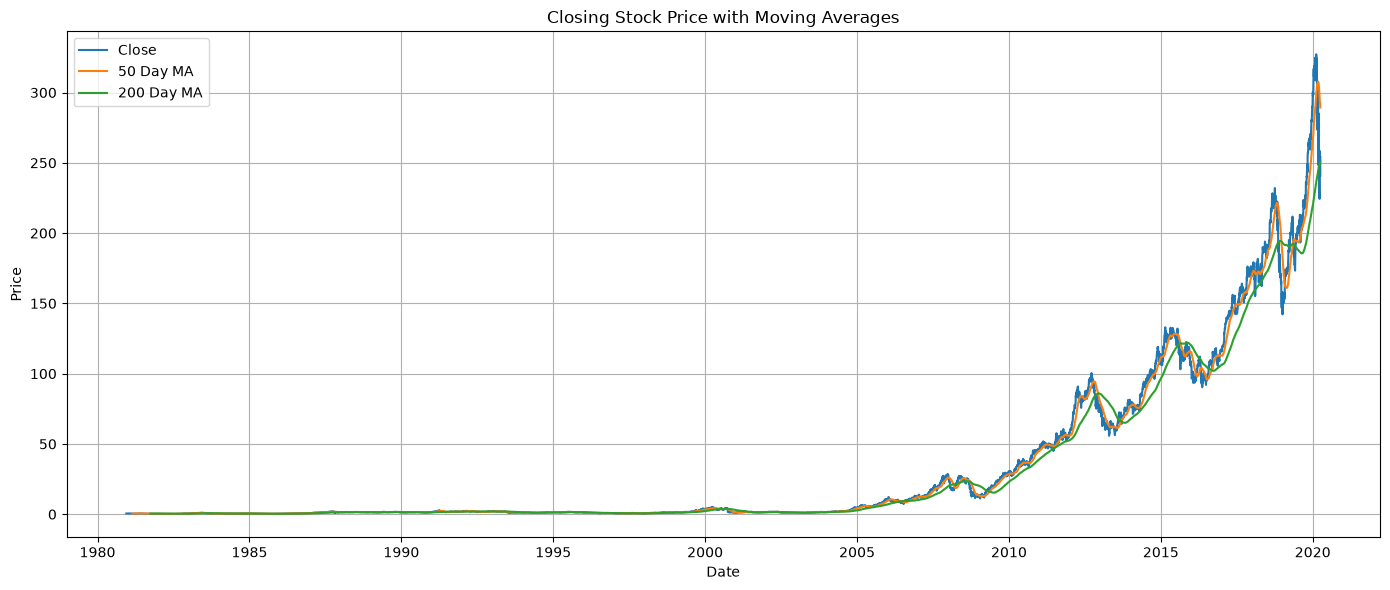

In [12]:
# Calculate Closing stock price with Moving Averages

df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()
plt.figure(figsize=(14,6))
plt.plot(df["Close"],label="Close")
plt.plot(df["MA50"],label="50 Day MA")
plt.plot(df["MA200"],label="200 Day MA")
plt.legend()
plt.title("Closing Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.tight_layout()
plt.savefig("closing_stock_price_with_moving_averages.png", dpi=300)
plt.show()

In [13]:
# Calculate the correlation matrix

corr = df.corr(numeric_only=True)

print(corr)

               Open      High       Low     Close  Adj Close    Volume  \
Open       1.000000  0.999935  0.999931  0.999878   0.998933 -0.133347   
High       0.999935  1.000000  0.999887  0.999929   0.999041 -0.132296   
Low        0.999931  0.999887  1.000000  0.999931   0.998992 -0.135045   
Close      0.999878  0.999929  0.999931  1.000000   0.999098 -0.133697   
Adj Close  0.998933  0.999041  0.998992  0.999098   1.000000 -0.142612   
Volume    -0.133347 -0.132296 -0.135045 -0.133697  -0.142612  1.000000   
MA50       0.996126  0.996444  0.995761  0.996034   0.994960 -0.132641   
MA200      0.988518  0.988691  0.988259  0.988395   0.986631 -0.145531   

               MA50     MA200  
Open       0.996126  0.988518  
High       0.996444  0.988691  
Low        0.995761  0.988259  
Close      0.996034  0.988395  
Adj Close  0.994960  0.986631  
Volume    -0.132641 -0.145531  
MA50       1.000000  0.993512  
MA200      0.993512  1.000000  


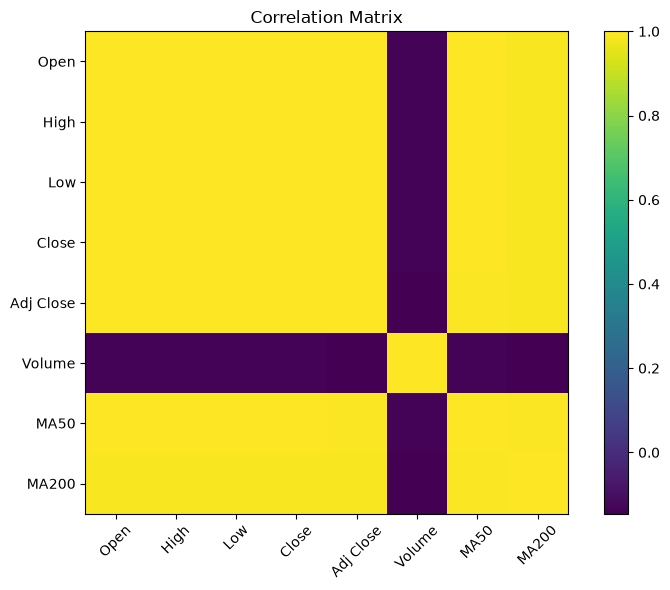

In [28]:
# Visualize the correlation matrix

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300)
plt.show()

In [4]:
data = df[['Close']]

In [5]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

(9909, 1)


In [6]:
sequence_length = 60

X = []

y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i,0])
    y.append(scaled_data[i,0])

X = np.array(X)

y = np.array(y)

print(X.shape)

print(y.shape)

(9849, 60)
(9849,)


In [7]:
X = np.reshape(X,(X.shape[0],X.shape[1],1))

print(X.shape)

(9849, 60, 1)


In [8]:
split = int(len(X)*0.8)

X_train = X[:split]

X_test = X[split:]

y_train = y[:split]

y_test = y[split:]

print(X_train.shape)

print(X_test.shape)

(7879, 60, 1)
(1970, 60, 1)


In [ ]:
# Build LSTM Model

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

lstm_model.add(Dropout(0.3))

lstm_model.add(LSTM(64))

lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(32, activation="relu"))

lstm_model.add(Dense(1))

lstm_model.summary()
        
#Compile the Model

lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)


# early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the LSTM Model

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


247/247 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - loss: 1.0415e-04 - val_loss: 8.3120e-04
Epoch 2/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 3.3075e-05 - val_loss: 3.4353e-04
Epoch 3/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - loss: 3.8539e-05 - val_loss: 0.0013
Epoch 4/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - loss: 3.4627e-05 - val_loss: 4.5423e-04
Epoch 5/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 2.9612e-05 - val_loss: 7.9333e-04
Epoch 6/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 2.7104e-05 - val_loss: 0.0040
Epoch 7/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 2.6469e-05 - val_loss: 2.9800e-04
Epoch 8/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - loss: 3.5324e-05 - val_loss: 0.0026
Epoch 9/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - loss: 2.9850e-05 - val_loss: 0.0011
Epoch 10/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 2.4537e-05 - val_loss: 0.0034
Epoch 11/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - los

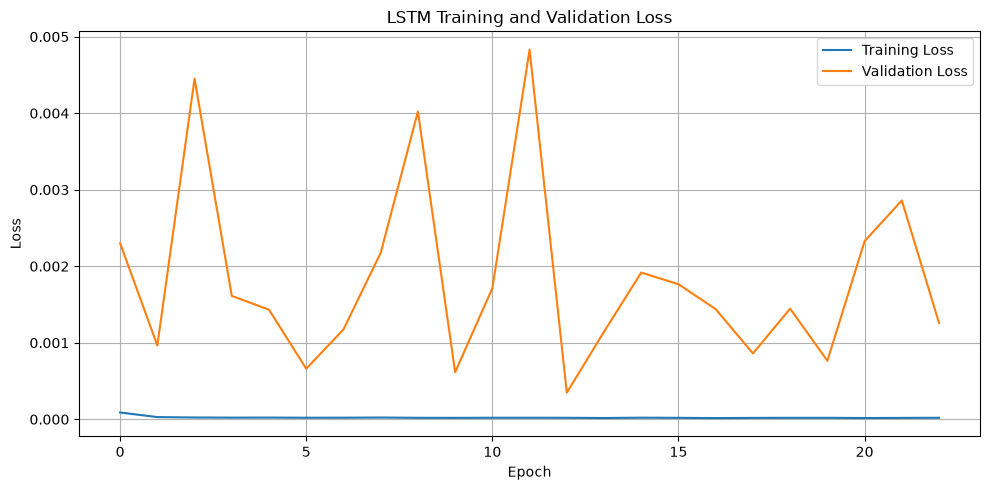

In [ ]:
# plot training and validation loss

plt.figure(figsize=(10,5))
plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lstm_training_validation_loss.png", dpi=300)
plt.show()

In [ ]:
# generate predictions
predictions = lstm_model.predict(X_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [ ]:
# convert predictions back to original scale

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [ ]:
# Evaluatation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(actual, predictions)

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

mape = np.mean(
    np.abs((actual-predictions)/actual)
) * 100

r2 = r2_score(actual, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R2 :", r2)

MAE : 3.9301346812756535
RMSE: 6.095995072314927
MAPE: 2.6981755844740807
R2 : 0.9888590398748737


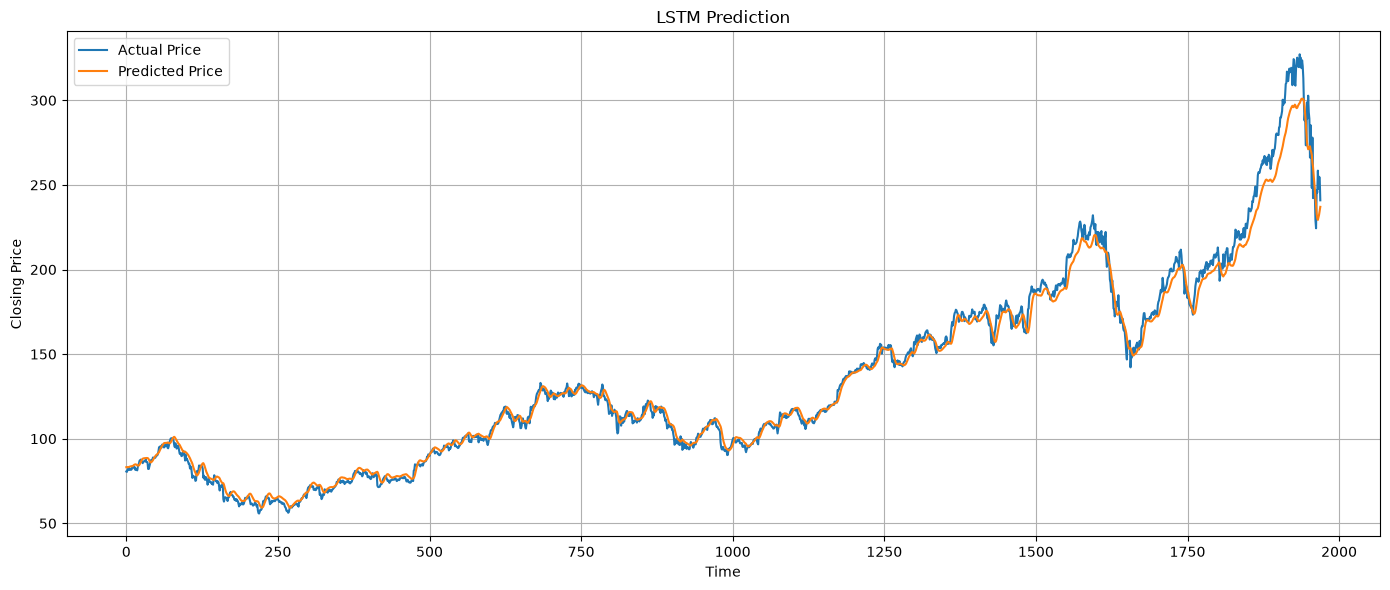

In [26]:
# plot actual vs predicted stock prices

plt.figure(figsize=(14,6))
plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("LSTM Prediction")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lstm_actual_vs_predicted.png", dpi=300)
plt.show()

In [27]:
#save the model
lstm_model.save("LSTM_Model_COM7019.keras")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# Build GRU Model (for regression - stock price prediction)
model = Sequential()

model.add(GRU(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))

# Dropout for regularization
model.add(Dropout(0.3))

model.add(GRU(units=64, return_sequences=False))

# Dropout for regularization
model.add(Dropout(0.3))

# Fully connected layer
model.add(Dense(32, activation='relu'))

# Output layer (regression - single value)
model.add(Dense(1))


# Compile Model

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


# Model Summary

model.summary()


# Training

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_40 (GRU)                    │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_41 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,937 (156.00 KB)

 Trainable params: 39,937 (156.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


247/247 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - loss: 1.2011e-04 - val_loss: 0.0014
Epoch 2/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - loss: 3.9423e-05 - val_loss: 0.0011
Epoch 3/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 2.8823e-05 - val_loss: 3.8422e-04
Epoch 4/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 2.5008e-05 - val_loss: 1.5204e-04
Epoch 5/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 4.3597e-05 - val_loss: 0.0012
Epoch 6/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - loss: 2.7227e-05 - val_loss: 0.0030
Epoch 7/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 2.8674e-05 - val_loss: 1.7037e-04
Epoch 8/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - loss: 2.5890e-05 - val_loss: 0.0017
Epoch 9/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 2.7382e-05 - val_loss: 3.4932e-04
Epoch 10/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - loss: 2.3866e-05 - val_loss: 0.0016
Epoch 11/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - loss: 2

In [ ]:
# Evaluate GRU model
gru_predictions = model.predict(X_test)

# Inverse transform predictions to original scale
gru_predictions = scaler.inverse_transform(gru_predictions)

# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gru = mean_absolute_error(actual, gru_predictions)
rmse_gru = np.sqrt(mean_squared_error(actual, gru_predictions))
mape_gru = np.mean(np.abs((actual - gru_predictions) / actual)) * 100
r2_gru = r2_score(actual, gru_predictions)

print("GRU Model Performance:")
print("MAE :", mae_gru)
print("RMSE:", rmse_gru)
print("MAPE:", mape_gru)
print("R2 :", r2_gru)

 1/62 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
GRU Model Performance:
MAE : 10.169188240942011
RMSE: 11.069646854899446
MAPE: 7.831134853480613
R2 : 0.963263232671483
LSTM vs GRU Comparison:
Metric     LSTM            GRU            
----------------------------------------
MAE        3.9301          10.1692        
RMSE       6.0960          11.0696        
MAPE       2.6982          7.8311         
R2         0.9889          0.9633         


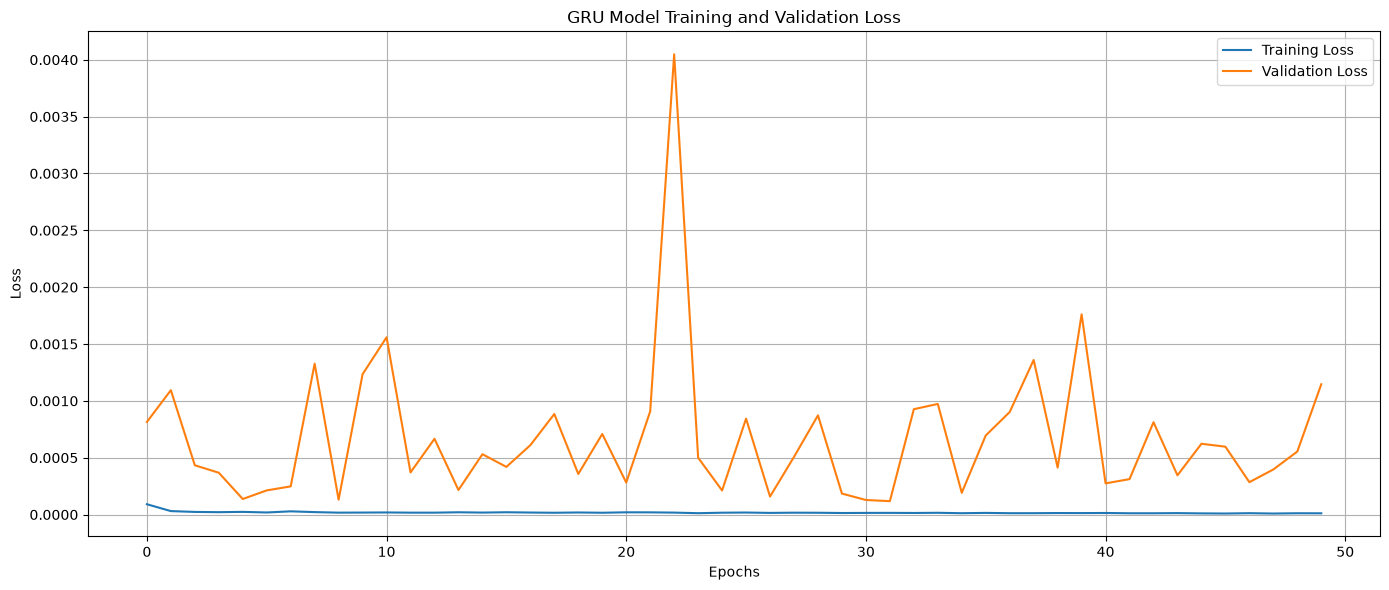

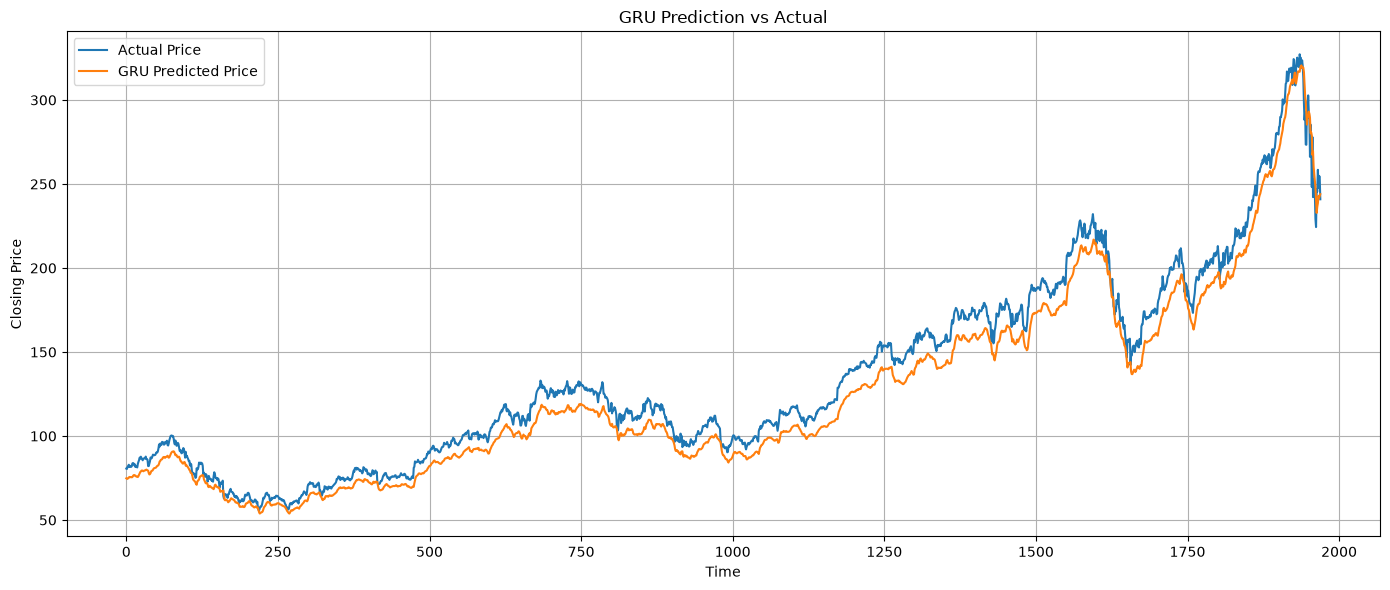

In [ ]:
# Plot GRU training history

plt.figure(figsize=(14,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('GRU Model Training and Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('gru_model_loss.png', dpi=300)
plt.show()

# Plot actual vs predicted for GRU
plt.figure(figsize=(14,6))
plt.plot(actual, label="Actual Price")
plt.plot(gru_predictions, label="GRU Predicted Price")
plt.title("GRU Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('gru_actual_vs_predicted.png', dpi=300)
plt.show()

In [ ]:
# Compare Metrics LSTM vs GRU

print("\n LSTM vs GRU Comparison\n")
print(f"{'Metric':<10} {'LSTM':<15} {'GRU':<15}")
print("-"*40)
print(f"{'MAE':<10} {mae:<15.4f} {mae_gru:<15.4f}")
print(f"{'RMSE':<10} {rmse:<15.4f} {rmse_gru:<15.4f}")
print(f"{'MAPE':<10} {mape:<15.4f} {mape_gru:<15.4f}")
print(f"{'R2':<10} {r2:<15.4f} {r2_gru:<15.4f}")


 LSTM vs GRU Comparison

Metric     LSTM            GRU            
----------------------------------------
MAE        3.9301          10.1692        
RMSE       6.0960          11.0696        
MAPE       2.6982          7.8311         
R2         0.9889          0.9633         


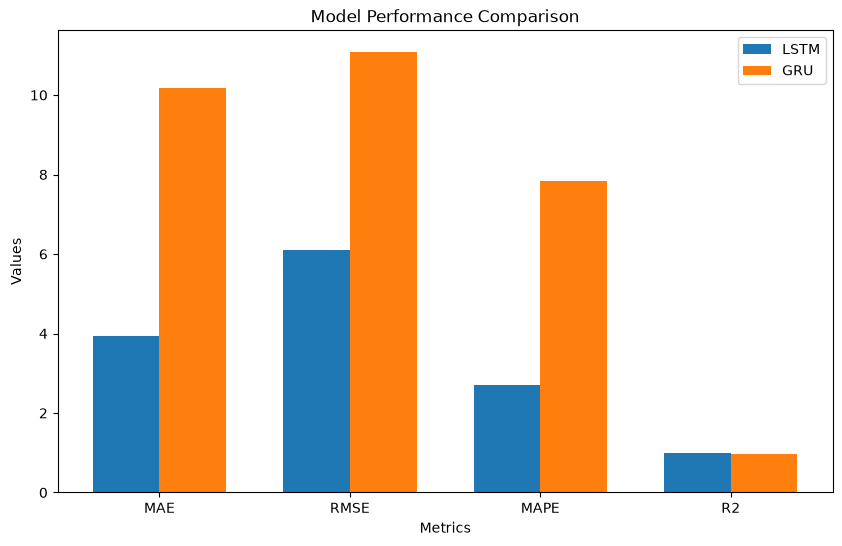

In [ ]:
# Plot comparison of evaluation metrics
metrics = ['MAE', 'RMSE', 'MAPE', 'R2']
lstm_metrics = [mae, rmse, mape, r2]
gru_metrics = [mae_gru, rmse_gru, mape_gru, r2_gru]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, lstm_metrics, width, label='LSTM')
plt.bar(x + width/2, gru_metrics, width, label='GRU')
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.show()


In [11]:
from tensorflow.keras.layers import Dropout

model.add(LSTM(64))
model.add(Dropout(0.3))

NameError: name 'model' is not defined